# Case III

This notebook reproduces the Case III plots seen in Sections 4.3 and B.2 of the paper.

The notebook contains:

1. A growth-family sweep at fixed $W_D = W_G = 2$ and $W_u = 64$ across $ES \in \{2000, 3000, 5000\}$.
2. Diffusion- and growth-function comparisons.
3. A matched-width sweep over $W_D = W_G \in \{2, 4, 8\}$ at fixed $W_u = 64$ for selected early-stopping value $ES=3000$.

*It produces plots for Fig. 9 and Figs. A3-A4 in the paper.*


In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import sympy as sp

PROJECT_ROOT = next(
    path
    for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (path / "Training").is_dir()
)
project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

from Training.JN.notebook_helpers.notebook_data import build_catalog, load_data_object, load_original_data
from Training.JN.notebook_helpers.notebook_config import (
    BCbool,
    BNdataLossFuncLabel,
    D_one_param_bool,
    binn_batch_size,
    binn_lr,
    binn_model_num,
    binn_rel_save_thresh,
    binn_rel_update_thresh,
    binnDevice,
    binnGenerateIndicesLabel,
    binnVF,
)
from Training.JN.notebook_helpers.notebook_models import (
    active_constraint_settings,
    build_model_catalog,
    build_model_path,
    filter_model_catalog,
    load_requested_models,
    summarize_requested_models,
)
from Training.JN.notebook_helpers.notebook_setup import bootstrap_notebook, register_notebook_pickle_globals

paths = bootstrap_notebook(PROJECT_ROOT)
PROJECT_ROOT = paths.project_root
JN_ROOT = paths.notebook_root

register_notebook_pickle_globals()

from paper_helpers import (
    scale_function_by_percent_error,
    plot_diff_mse_lst,
    plot_eval_D_multi_gray,
    plot_eval_G_multi_gray,
    plot_final_loss_lst,
    plot_grow_mse_lst_extended,
    plot_total_run_times_lst,
    plot_initial_condition_1d,
)
from Training.data.python.pipeline.config.store import (
    growth_func1,
    growth_func2,
    growth_func3,
    growth_func4,
)


## 1. Load the Case III data

We first recover the simulated reaction-diffusion dataset used throughout Case III, then define a small helper for swapping only the growth law while holding the remaining data assumptions fixed. This matches the Case I notebook's pattern of validating the data objects before any model analysis begins. The spatial and temporal grids follow [Lagergren et al. (2020)](https://doi.org/10.1371/journal.pcbi.1008462)

MSE between u and u_clean: 0.0
ABS between u and u_clean [cells]: 0.0
ABS (%) between u and u_clean: 0.0


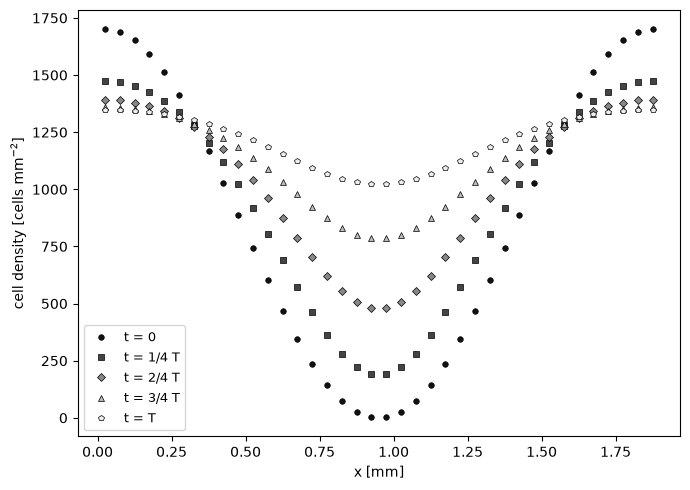

In [2]:
DATA_ROOT = paths.data_root

original_data_obj = load_original_data(DATA_ROOT)
x = original_data_obj.x
t = original_data_obj.t
K = 1  # Densities are normalized so the effective carrying capacity is 1.

data_df = build_catalog(DATA_ROOT, target_filename="data_obj.npy")
GROWTH_FAMILY_LABELS = ["const", "linear", "quadratic", "exp"]

CASE3_BASE_DATA_CONFIG = {
    "dataX1num": len(x),
    "dataX2num": 1,
    "dataTnum": len(t),
    "dataK": K,
    "dataICLabel": "cos",
    "dataDiffLabel": "const",
    "dataGrowLabel": "linear",
    "dataGamma": 0,
    "dataNoisePercent": 0,
    "dataNoiseSeed": 0,
}
CASE3_DATA_CONFIG = CASE3_BASE_DATA_CONFIG.copy()


def build_case3_data_config(grow_label=None, overrides=None):
    config = CASE3_BASE_DATA_CONFIG.copy()
    if grow_label is not None:
        config["dataGrowLabel"] = grow_label
    if overrides:
        config |= overrides
    return config


def load_case3_data_obj(grow_label=None):
    data_obj, _ = load_data_object(
        build_case3_data_config(grow_label=grow_label),
        DATA_ROOT,
        data_df=data_df,
    )
    return data_obj


data_obj = load_case3_data_obj(CASE3_DATA_CONFIG["dataGrowLabel"])
plot_initial_condition_1d(data_obj)


## 2. Build the Case III model catalogue & form helper functions for model loading and plotting


### 2.1. Catalogue trained model

Next we catalogue all saved BINN checkpoints under `Training/binn`, filter them to the fixed Case III assumptions, and display the subset that should support the sweeps below.

The preview table is intentionally compact. The varying dimensions in this notebook are `dataGrowLabel`, `binnES`, `binnDsize`, `binnUsize`, and `binnTVsplitSeed`; everything else is held fixed for Case III.


In [3]:
BINN_ROOT = paths.binn_root
binn_df = build_model_catalog(BINN_ROOT)

CASE3_NUM_PDE_SAMPLES = 100
ALL_CONSTRAINTS = True
CONSTRAINT_TUPLE = (True, True, True, True)
CONSTRAINT_WEIGHTS = {
    "D_bound_weight": 0,
    "D_mono_weight": 1e1,
    "G_bound_weight": 0,
    "G_mono_weight": 1e1,
}
CONSTRAINT_BOUNDS = {
    "D_bound": (0, 0.1),
    "G_bound": (-0.02 / (1 / 24), 0.1 / (1 / 24)),
}
FIXED_G_WIDTH = 2

CASE3_FIXED_FILTERS = CASE3_DATA_CONFIG | {
    "binnVF": binnVF,
    "binnGenerateIndicesLabel": binnGenerateIndicesLabel,
    "binnGsize": FIXED_G_WIDTH,
    "DoneParamBool": D_one_param_bool,
    "binnDevice": binnDevice,
    "allConstraints": ALL_CONSTRAINTS,
    "BCbool": BCbool,
    "numPDEsamples": CASE3_NUM_PDE_SAMPLES,
    "binnLR": binn_lr,
    "binnBatchSize": binn_batch_size,
    "binnRelUpdateThresh": binn_rel_update_thresh,
    "binnRelSaveThresh": binn_rel_save_thresh,
    "BNdataLossFuncLabel": BNdataLossFuncLabel,
}
if ALL_CONSTRAINTS:
    CASE3_FIXED_FILTERS |= active_constraint_settings(
        CONSTRAINT_TUPLE,
        CONSTRAINT_WEIGHTS,
        CONSTRAINT_BOUNDS,
    )

case3_catalog = filter_model_catalog(
    binn_df,
    CASE3_FIXED_FILTERS,
    empty_message="No BINN models were found for the fixed Case III assumptions used in this notebook.",
)

CATALOG_COLUMNS = [
    "binnES",
    "binnDsize",
    "binnUsize",
    "binnTVsplitSeed",
    "full_path",
]
case3_catalog = case3_catalog.sort_values(
    ["binnES", "binnDsize", "binnUsize", "binnTVsplitSeed"]
).reset_index(drop=True)
case3_catalog[CATALOG_COLUMNS]


,binnES,binnDsize,binnUsize,binnTVsplitSeed,full_path
0,2000,2,64,0,/Users/willa954/Desktop/Git-personal/Hyperpara...
1,2000,2,64,1,/Users/willa954/Desktop/Git-personal/Hyperpara...
2,2000,2,64,2,/Users/willa954/Desktop/Git-personal/Hyperpara...
3,3000,2,64,0,/Users/willa954/Desktop/Git-personal/Hyperpara...
4,3000,2,64,1,/Users/willa954/Desktop/Git-personal/Hyperpara...
5,3000,2,64,2,/Users/willa954/Desktop/Git-personal/Hyperpara...
6,5000,2,64,0,/Users/willa954/Desktop/Git-personal/Hyperpara...
7,5000,2,64,1,/Users/willa954/Desktop/Git-personal/Hyperpara...
8,5000,2,64,2,/Users/willa954/Desktop/Git-personal/Hyperpara...


### 2.2. Helper functions for loading trained models


In [4]:
def build_case3_model_path(d_width, u_width, split_seed, binn_es, overrides=None):
    dynamic_info = {
        "binnTVsplitSeed": split_seed,
        "binnUsize": u_width,
        "binnDsize": d_width,
        "binnES": binn_es,
    }

    return build_model_path(
        BINN_ROOT,
        CASE3_FIXED_FILTERS | (overrides or {}),
        dynamic_info,
        model_df=case3_catalog,
        model_label=binn_model_num,
    )


def iter_requested_case3_paths(es_values, d_sizes, u_sizes, split_seeds):
    for binn_es in es_values:
        for d_width in d_sizes:
            for u_width in u_sizes:
                for split_seed in split_seeds:
                    yield {
                        "binnES": binn_es,
                        "binnDsize": d_width,
                        "binnUsize": u_width,
                        "binnTVsplitSeed": split_seed,
                        "path": build_case3_model_path(
                            d_width,
                            u_width,
                            split_seed,
                            binn_es,
                        ),
                    }


def build_growth_family_requested_paths(es_values, d_size, u_size, split_seeds, grow_labels):
    requested_models = []
    for binn_es in es_values:
        for grow_label in grow_labels:
            for split_seed in split_seeds:
                requested_models.append(
                    {
                        "binnES": binn_es,
                        "dataGrowLabel": grow_label,
                        "binnTVsplitSeed": split_seed,
                        "path": build_case3_model_path(
                            d_size,
                            u_size,
                            split_seed,
                            binn_es,
                            overrides={"dataGrowLabel": grow_label},
                        ),
                    }
                )
    return requested_models


def load_case3_models_by_growth_family(es_values, d_size, u_size, split_seeds, grow_labels):
    return load_requested_models(
        build_growth_family_requested_paths(
            es_values,
            d_size,
            u_size,
            split_seeds,
            grow_labels,
        ),
        device=binnDevice,
        group_keys=("binnES", "dataGrowLabel", "binnTVsplitSeed"),
    )


def build_width_family_requested_paths(width_values, es_value, u_size, split_seeds, grow_labels):
    requested_models = []
    for width in width_values:
        for grow_label in grow_labels:
            for split_seed in split_seeds:
                requested_models.append(
                    {
                        "binnDsize": width,
                        "dataGrowLabel": grow_label,
                        "binnTVsplitSeed": split_seed,
                        "path": build_case3_model_path(
                            width,
                            u_size,
                            split_seed,
                            es_value,
                            overrides={"dataGrowLabel": grow_label, "binnGsize": width},
                        ),
                    }
                )
    return requested_models


def summarize_case3_models_by_width(width_values, es_value, u_size, split_seeds, grow_labels):
    requested_paths = []
    for width in width_values:
        for grow_label in grow_labels:
            for split_seed in split_seeds:
                file_path = build_case3_model_path(
                    width,
                    u_size,
                    split_seed,
                    es_value,
                    overrides={"dataGrowLabel": grow_label, "binnGsize": width},
                )
                requested_paths.append((width, grow_label, split_seed, file_path))

    existing_paths = [entry for entry in requested_paths if entry[-1].exists()]
    missing_paths = [entry for entry in requested_paths if not entry[-1].exists()]

    print(f"Requested width-sweep model combinations: {len(requested_paths)}")
    print(f"Already trained width-sweep model files found: {len(existing_paths)}")
    print(f"Missing width-sweep model files: {len(missing_paths)}")
    if missing_paths:
        first_missing = missing_paths[0]
        print(
            {
                "binnDsize": first_missing[0],
                "binnGsize": first_missing[0],
                "dataGrowLabel": first_missing[1],
                "binnTVsplitSeed": first_missing[2],
                "path": first_missing[3],
            }
        )

    return {
        "requested_count": len(requested_paths),
        "trained_count": len(existing_paths),
        "missing_count": len(missing_paths),
        "missing_paths": [entry[-1] for entry in missing_paths],
    }


def load_case3_models_by_width(width_values, es_value, u_size, split_seeds, grow_labels):
    return load_requested_models(
        build_width_family_requested_paths(
            width_values,
            es_value,
            u_size,
            split_seeds,
            grow_labels,
        ),
        device=binnDevice,
        group_keys=("binnDsize", "dataGrowLabel", "binnTVsplitSeed"),
    )


### 2.3 Shared plotting style

These settings are reused across the Case III diagnostics, growth-family comparisons, and width-sweep figures.


In [5]:
BLUE_COLORS = ["#0033A0", "#1E90FF", "#6699CC", "#A4C8E1", "#D6EAF8"]
D_COLORS = ["#8B2500", "#FF7F0E", "#FDB863", "#FDD9B5", "#FFF1E0"]
G_COLORS = ["#00441B", "#1A9850", "#66C2A4", "#B2E2E2", "#E5F5F9"]
linestyles = ["-"] * 5
MARKER_STYLES = ["o"] * 5
LEGEND_SIZE = 16
LEGEND_SIZE_LARGE = 18
FONTSIZES = {
    "xaxis": 18,
    "xtick_labels": 16,
    "yaxis": 18,
    "ytick_labels": 16,
}


def plot_params_from_models(models_dict, colors):
    labels = [str(key) for key in models_dict.keys()]
    return {
        key: [colors[i], linestyles[i], MARKER_STYLES[i], labels[i]]
        for i, key in enumerate(models_dict.keys())
    }


def ground_truth_diffusion(u):
    return data_obj.theta_D * np.ones_like(u)


GROWTH_TEMPLATES = {
        "zero": growth_func1,
        "const": growth_func1,
        "linear": growth_func2,
        "quadratic": growth_func3,
        "exp": growth_func4,
}


def resolve_growth_template(growth_label):
    try:
        return GROWTH_TEMPLATES[growth_label]
    except KeyError as exc:
        raise ValueError(f"Unknown growth label: {growth_label!r}") from exc


def make_ground_truth_diffusion_symbolic(current_data_obj):
    return sp.sympify(current_data_obj.theta_D)


def make_ground_truth_growth(growth_label, current_data_obj):
    growth_template = resolve_growth_template(growth_label)

    def growth(u):
        return growth_template(u, current_data_obj.theta_G)

    return growth


def make_ground_truth_growth_symbolic(growth_label, current_data_obj):
    u = sp.Symbol("u")
    theta_G = np.atleast_1d(current_data_obj.theta_G)
    growth_label = "const" if growth_label == "zero" else growth_label

    if growth_label == "const":
        return sp.sympify(theta_G[0]) / 2
    if growth_label == "linear":
        return (sp.sympify(theta_G[0]) + sp.sympify(theta_G[1]) * u) / 2
    if growth_label == "quadratic":
        return (sp.sympify(theta_G[0]) + sp.sympify(theta_G[1]) * u**2) / 2
    if growth_label == "exp":
        return (
            sp.sympify(theta_G[0])
            + sp.sympify(theta_G[1]) * (1 - sp.exp(-sp.sympify(theta_G[2]) * u))
        ) / 2

    raise ValueError(f"Unknown growth label: {growth_label!r}")


def compute_scaled_mse(func, beta, n_points=1001):
    k = 1.0 + beta / 100.0
    u = np.linspace(0.0, 1.0, n_points)
    values = np.array([func(ui) for ui in u])
    return np.mean(((k * values) - values) ** 2)


RAW_MSES_DIFF = [0.5, 1, 2]
MSES_DIFF = [scale_function_by_percent_error(ground_truth_diffusion, beta=mse)[1] for mse in RAW_MSES_DIFF]


def make_case3_output_dir(*parts):
    output_dir = JN_ROOT / "pngs" / "1D" / "case3"
    for part in parts:
        output_dir = output_dir / str(part)
    os.makedirs(output_dir, exist_ok=True)
    return output_dir


## 3. Sweep A: vary growth-law family (and $ES$) at fixed $W_D = W_G = 2$ and $W_u = 64$

This section reproduces the main Case III sweep over growth families. We keep the architecture fixed, compare the four growth-law families across early-stopping values, and then evaluate the learned diffusion and growth functions directly against their analytical references.


In [6]:
ES_VALUES = [2000, 3000, 5000]
FIXED_D_WIDTH = FIXED_G_WIDTH
FIXED_U_WIDTH = 64
TV_SPLIT_SEEDS = [0, 1, 2]
SELECTED_ES = ES_VALUES[0]
ES_LABELS = [str(binn_es) for binn_es in ES_VALUES]

FIGURE_A3_DIR = make_case3_output_dir("figA3")
FIGURE_A4_DIR = make_case3_output_dir("figA4")
FIGURE_9_DIR = make_case3_output_dir("fig9")

# Load the growth-family models used throughout Sweep A.
growth_family_models_by_es = load_case3_models_by_growth_family(
    es_values=ES_VALUES,
    d_size=FIXED_D_WIDTH,
    u_size=FIXED_U_WIDTH,
    split_seeds=TV_SPLIT_SEEDS,
    grow_labels=GROWTH_FAMILY_LABELS,
)
growth_family_models_by_es_list = [
    growth_family_models_by_es[binn_es]
    for binn_es in ES_VALUES
]

growth_family_loss_plot_params = plot_params_from_models(
    growth_family_models_by_es[SELECTED_ES],
    BLUE_COLORS[: len(GROWTH_FAMILY_LABELS)],
)
growth_family_mse_plot_params = plot_params_from_models(
    growth_family_models_by_es[SELECTED_ES],
    G_COLORS[: len(GROWTH_FAMILY_LABELS)],
)
diffusion_family_plot_params = plot_params_from_models(
    growth_family_models_by_es[SELECTED_ES],
    D_COLORS[: len(GROWTH_FAMILY_LABELS)],
)


All x-axis labels found (ordered): ['const', 'linear', 'quadratic', 'exp']


/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_final_loss.py:216: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax1.grid(bool(grid), axis="y", which="both", linestyle="-", linewidth=0.5, alpha=grid_alpha)


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/figA3/plot_a


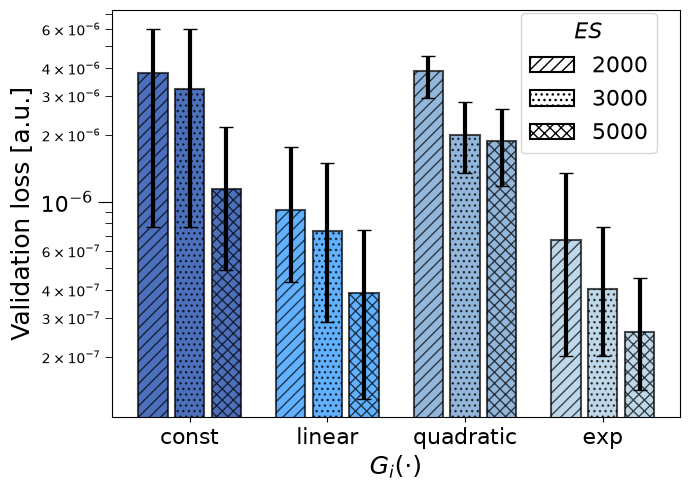

All x-axis labels found (ordered): ['const', 'linear', 'quadratic', 'exp']
Mean runtime increases between corresponding models across groups:
  2000 -> 3000
    const: 344.534s -> 389.378s (delta +44.844s)
    linear: 287.291s -> 362.402s (delta +75.110s)
    quadratic: 324.257s -> 557.817s (delta +233.560s)
    exp: 301.116s -> 407.792s (delta +106.676s)
    mean delta: +115.048s
  3000 -> 5000
    const: 389.378s -> 776.196s (delta +386.818s)
    linear: 362.402s -> 664.618s (delta +302.217s)
    quadratic: 557.817s -> 641.514s (delta +83.697s)
    exp: 407.792s -> 598.674s (delta +190.882s)
    mean delta: +240.903s
saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/figA3/plot_b


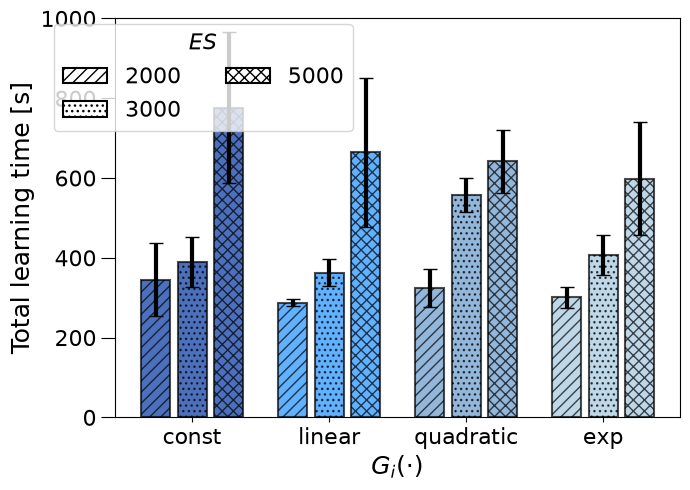

All x-axis labels found (ordered): ['const', 'linear', 'quadratic', 'exp']
saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/figA3/plot_c


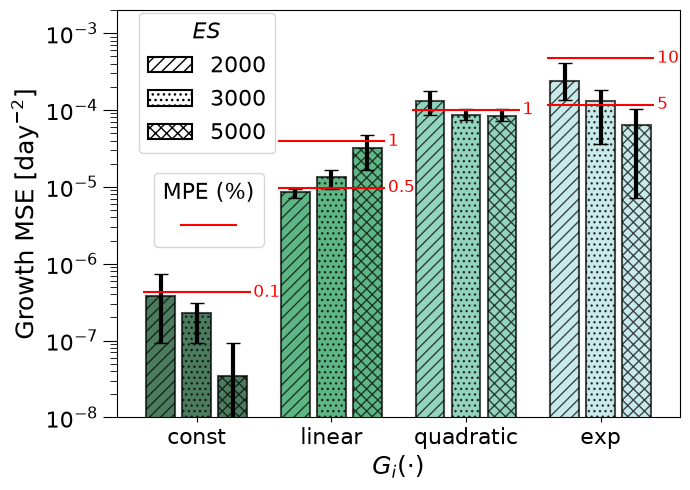

All x-axis labels found (ordered): ['const', 'linear', 'quadratic', 'exp']
saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/figA4/plot_d


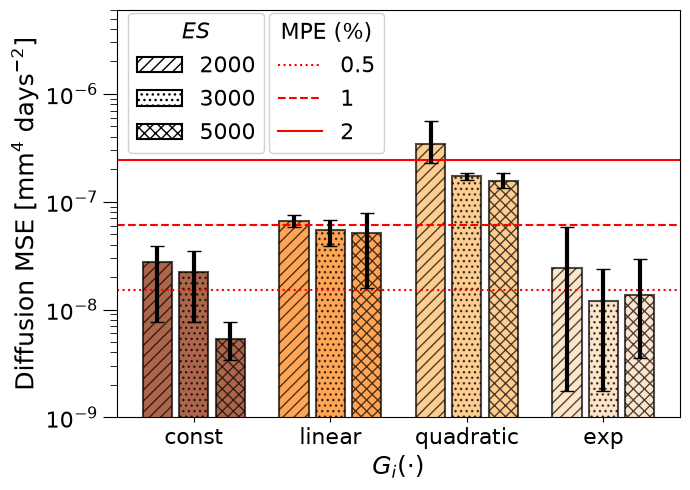

In [7]:
growth_family_beta_list_nested = [[0.1], [0.5, 1], [1], [5, 10]]
hatch_patterns = ("///", "...", "xxx")

flat_beta_values = [value for row in growth_family_beta_list_nested for value in row]
unique_beta_values = list(dict.fromkeys(flat_beta_values))
dash_patterns = [
    (0, (1, 1)),
    (0, (3, 1)),
    (0, (5, 1)),
    (0, (1, 2)),
    (0, (3, 2)),
    (0, (5, 2)),
    (0, (1, 3)),
    (0, (3, 3)),
]
if len(unique_beta_values) > len(dash_patterns):
    raise ValueError("Add more dash patterns for growth-family MPE overlays.")

style_map = dict(zip(unique_beta_values, dash_patterns))
growth_family_pe_linestyles_nested = [
    [style_map[value] for value in row]
    for row in growth_family_beta_list_nested
]

growth_family_mses_nested = []
for family_label, beta_values in zip(GROWTH_FAMILY_LABELS, growth_family_beta_list_nested):
    family_data_obj = load_case3_data_obj(grow_label=family_label)
    family_ground_truth_growth = make_ground_truth_growth(family_label, family_data_obj)
    growth_family_mses_nested.append(
        [compute_scaled_mse(family_ground_truth_growth, beta=beta) for beta in beta_values]
    )


# First plot of first row of figure A3
# ===================================
plot_final_loss_lst(
    growth_family_models_by_es_list,
    plot_params=growth_family_loss_plot_params,
    label_list=ES_LABELS,
    name=str(FIGURE_A3_DIR / "plot_a"),
    bbox_to_anchor=(0.7, 1.02),
    y_label="Validation loss [a.u.]",
    legend_size=LEGEND_SIZE,
    x_label=r"$G_i(\cdot)$",
    figsize=(7, 5),
    axis_fontsizes=FONTSIZES,
    legend_title=r"$ES$",
    hatch_patterns=hatch_patterns,
)


# Second plot of first row of figure A3
# ===================================
plot_total_run_times_lst(
    models_dics_list=growth_family_models_by_es_list,
    plot_params=growth_family_loss_plot_params,
    label_list=ES_LABELS,
    legend_pos=(0.44, 0.69),
    legend_fontsize=LEGEND_SIZE,
    y_label="Total learning time [s]",
    x_label=r"$G_i(\cdot)$",
    name=str(FIGURE_A3_DIR / "plot_b"),
    figsize=(7, 5),
    legend_ncols=2,
    axis_fontsizes=FONTSIZES,
    y_scale="linear",
    y_lim=[0, 1000],
    legend_title=r"$ES$",
    hatch_patterns=hatch_patterns,
)


# First plot of second row of figure A3
# ===================================
plot_grow_mse_lst_extended(
    models_dics_list=growth_family_models_by_es_list,
    plot_params=growth_family_mse_plot_params,
    label_list=ES_LABELS,
    name=str(FIGURE_A3_DIR / "plot_c"),
    figsize=(7, 5),
    colors=G_COLORS[: len(GROWTH_FAMILY_LABELS)],
    bbox_to_anchor=(0.3, 1.02),
    legend_size=LEGEND_SIZE,
    pe_bbox_to_anchor_offset=(-0.04, -0.42),
    pe_label_list_nested=growth_family_beta_list_nested,
    pe_values_nested=growth_family_mses_nested,
    pe_linestyles_nested=growth_family_pe_linestyles_nested,
    pe_legend_ncols=4,
    y_label=r"Growth MSE [day$^{-2}$]",
    pe_legend_title="MPE (%)",
    legend_title=r"$ES$",
    x_label=r"$G_i(\cdot)$",
    y_lim=(1e-8, 2e-3),
    hatch_patterns=hatch_patterns,
    axis_fontsizes=FONTSIZES,
)

# Second plot of second row of figure A3
# ===================================
plot_diff_mse_lst(
    models_dics_list=growth_family_models_by_es_list,
    plot_params=diffusion_family_plot_params,
    label_list=ES_LABELS,
    name=str(FIGURE_A4_DIR / "plot_d"),
    figsize=(7, 5),
    colors=D_COLORS[: len(GROWTH_FAMILY_LABELS)],
    bbox_to_anchor=(0, 1.02),
    legend_size=LEGEND_SIZE,
    pe_bbox_to_anchor_offset=(0.25, 0),
    pe_label_list=[f"{mpe}" for mpe in RAW_MSES_DIFF],
    pe_values=MSES_DIFF,
    pe_linestyles=(":", "--", "-", "-."),
    pe_legend_ncols=1,
    pe_legend_title="MPE (%)",
    x_label=r"$G_i(\cdot)$",
    axis_fontsizes=FONTSIZES,
    ylim=(1e-9, 6e-6),
    hatch_patterns=hatch_patterns,
    legend_title=r"$ES$",
)


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/fig9/plot_diff_const.png


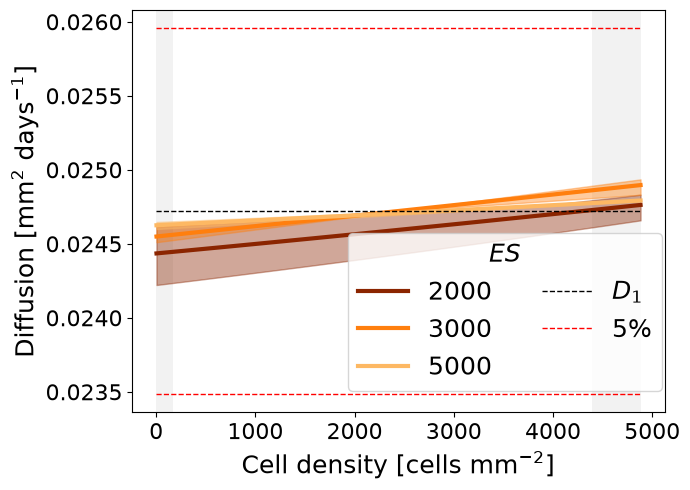

saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/fig9/plot_grow_const.png


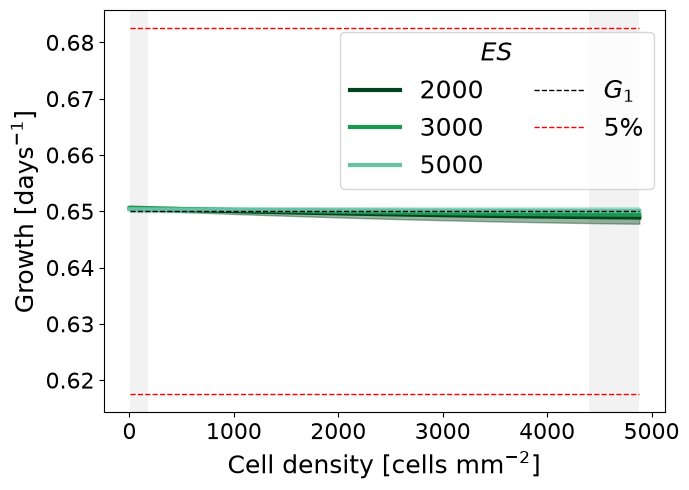

saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/fig9/plot_diff_linear.png


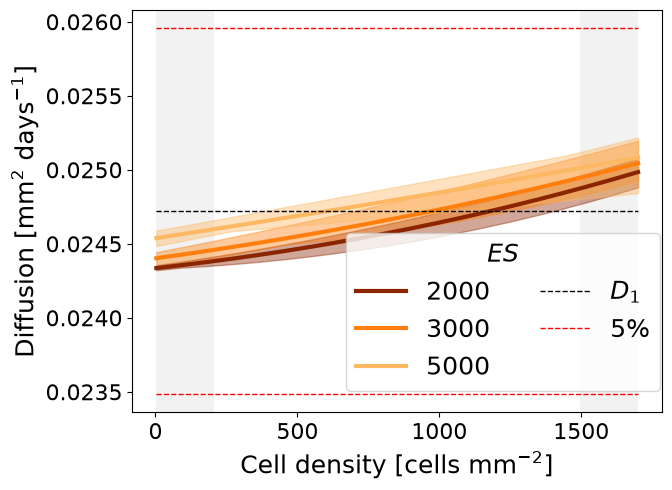

saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/fig9/plot_grow_linear.png


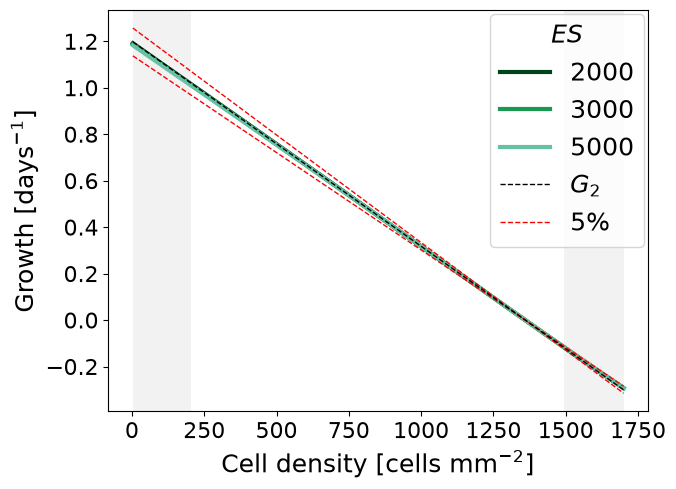

saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/fig9/plot_diff_quadratic.png


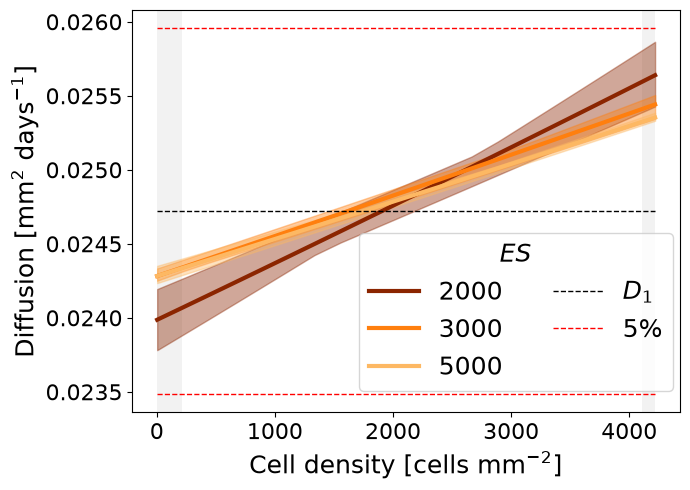

saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/fig9/plot_grow_quadratic.png


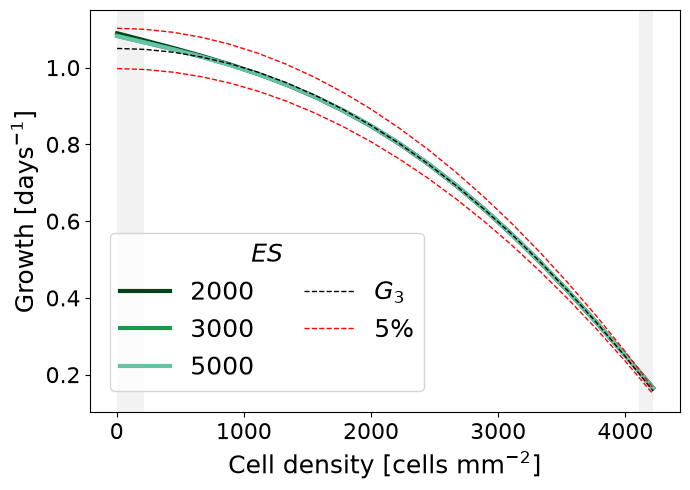

saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/fig9/plot_diff_exp.png


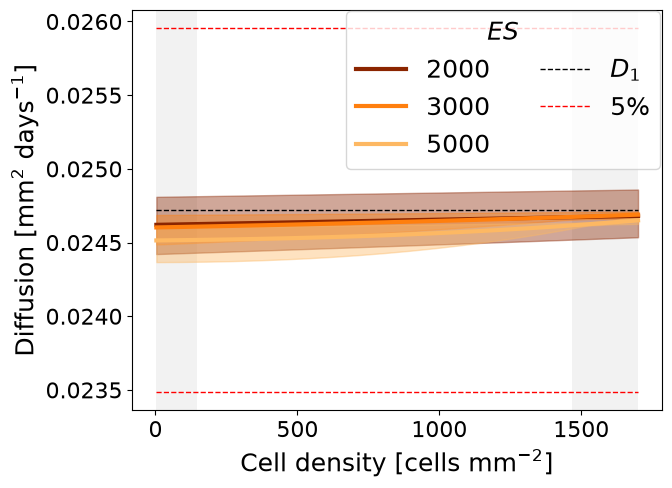

saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/fig9/plot_grow_exp.png


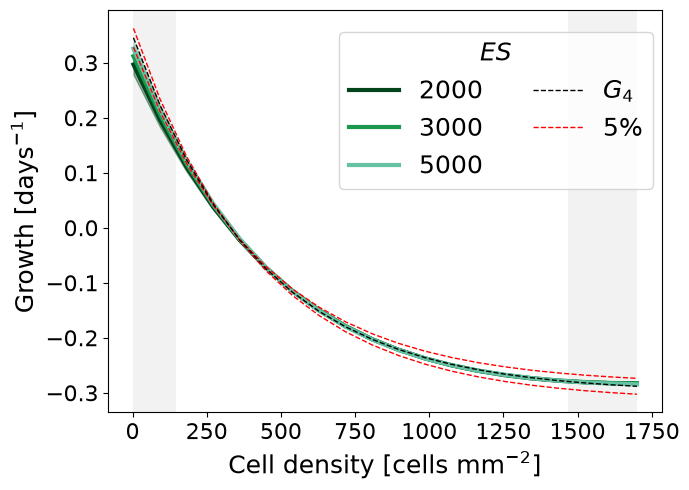

In [8]:
# Function-space comparisons for Sweep A.
diffusion_legend_positions = [(0.7, 0.25), (0.7, 0.25), (0.7, 0.25), (0.7, 0.8)]
growth_legend_positions = [(0.7, 0.75), (0.85, 0.7), (0.3, 0.25), (0.7, 0.75)]

# Produces plots for figure 9 in the paper
# ===================================
for i, family_label in enumerate(GROWTH_FAMILY_LABELS):
    family_data_obj = load_case3_data_obj(grow_label=family_label)

    diffusion_models_by_es = {
        binn_es: growth_family_models_by_es[binn_es][family_label]
        for binn_es in ES_VALUES
    }
    diffusion_labels_by_es = [str(binn_es) for binn_es in diffusion_models_by_es.keys()]
    diffusion_symbolic_truths_by_es = [
        make_ground_truth_diffusion_symbolic(family_data_obj)
        for _ in diffusion_labels_by_es
    ]
    
    # first row
    plot_eval_D_multi_gray(
        diffusion_models_by_es,
        family_data_obj,
        diffusion_symbolic_truths_by_es,
        D_COLORS[: len(diffusion_labels_by_es)],
        diffusion_labels_by_es,
        Dnum=1,
        device="cpu",
        num_bins=50,
        K=1700,
        name=str(FIGURE_9_DIR / f"plot_diff_{family_label}.png"),
        fill=True,
        legend_pos=diffusion_legend_positions[i],
        legend_ncols=2,
        legend_title="$ES$",
        linestyles=["-"] * len(diffusion_labels_by_es),
        errs=[5, 5],
        figsize=(7, 5),
        axis_fontsizes=FONTSIZES,
        legend_fontsize=LEGEND_SIZE_LARGE,
    )

    growth_models_by_es = {
        binn_es: growth_family_models_by_es[binn_es][family_label]
        for binn_es in ES_VALUES
    }
    growth_labels_by_es = [str(binn_es) for binn_es in growth_models_by_es.keys()]
    growth_symbolic_truths_by_es = [
        make_ground_truth_growth_symbolic(family_label, family_data_obj)
        for _ in growth_labels_by_es
    ]
    
    # second row
    plot_eval_G_multi_gray(
        growth_models_by_es,
        family_data_obj,
        growth_symbolic_truths_by_es,
        G_COLORS[: len(growth_labels_by_es)],
        growth_labels_by_es,
        Gnum={i+1},
        device="cpu",
        num_bins=50,
        K=1700,
        name=str(FIGURE_9_DIR / f"plot_grow_{family_label}.png"),
        fill=True,
        legend_pos=growth_legend_positions[i],
        legend_ncols=1 if i == 1 else 2,
        legend_fontsize=LEGEND_SIZE_LARGE,
        legend_title="$ES$",
        linestyles=["-"] * len(growth_labels_by_es),
        errs=[5, 5],
        figsize=(7, 5),
        axis_fontsizes=FONTSIZES,
    )


## 4. Sweep B configuration: vary $W_D = W_G$ at fixed $W_u = 64$ for a selected $ES$

The final section mirrors the growth-family comparison above, but now holds the early-stopping value fixed and compares the matched architectural widths $W_D = W_G \in \{2, 4, 8\}$ across the same growth-law families.


In [9]:
WIDTH_SWEEP_VALUES = [2, 4, 8]
SELECTED_ES_FOR_WIDTH_SWEEP = ES_VALUES[1] if len(ES_VALUES) > 1 else ES_VALUES[0]
WIDTH_LABELS = [f"{width}" for width in WIDTH_SWEEP_VALUES]

summarize_case3_models_by_width(
    width_values=WIDTH_SWEEP_VALUES,
    es_value=SELECTED_ES_FOR_WIDTH_SWEEP,
    u_size=FIXED_U_WIDTH,
    split_seeds=TV_SPLIT_SEEDS,
    grow_labels=GROWTH_FAMILY_LABELS,
)

width_family_models = load_case3_models_by_width(
    width_values=WIDTH_SWEEP_VALUES,
    es_value=SELECTED_ES_FOR_WIDTH_SWEEP,
    u_size=FIXED_U_WIDTH,
    split_seeds=TV_SPLIT_SEEDS,
    grow_labels=GROWTH_FAMILY_LABELS,
)
width_family_models_list = [width_family_models[width] for width in WIDTH_SWEEP_VALUES]

width_family_loss_plot_params = plot_params_from_models(
    width_family_models[WIDTH_SWEEP_VALUES[0]],
    BLUE_COLORS[: len(GROWTH_FAMILY_LABELS)],
)
width_family_mse_plot_params = plot_params_from_models(
    width_family_models[WIDTH_SWEEP_VALUES[0]],
    G_COLORS[: len(GROWTH_FAMILY_LABELS)],
)
width_diffusion_plot_params = plot_params_from_models(
    width_family_models[WIDTH_SWEEP_VALUES[0]],
    D_COLORS[: len(GROWTH_FAMILY_LABELS)],
)


Requested width-sweep model combinations: 36
Already trained width-sweep model files found: 36
Missing width-sweep model files: 0


All x-axis labels found (ordered): ['const', 'linear', 'quadratic', 'exp']


/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_final_loss.py:216: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax1.grid(bool(grid), axis="y", which="both", linestyle="-", linewidth=0.5, alpha=grid_alpha)


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/figA4/plot_a


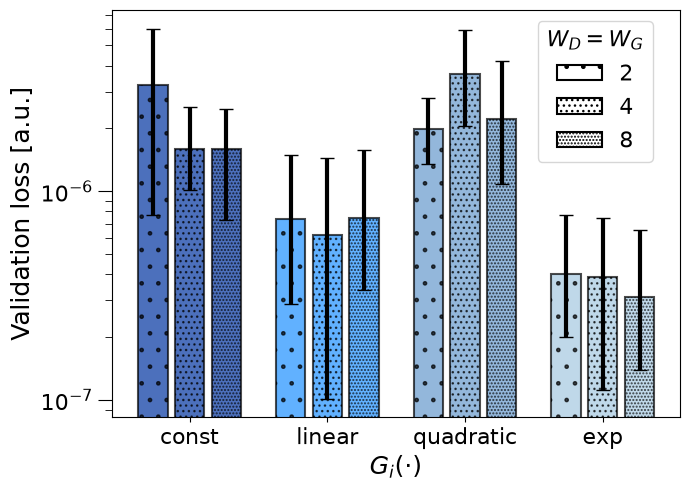

All x-axis labels found (ordered): ['const', 'linear', 'quadratic', 'exp']
Mean runtime increases between corresponding models across groups:
  2 -> 4
    const: 389.378s -> 437.890s (delta +48.512s)
    linear: 362.402s -> 352.883s (delta -9.518s)
    quadratic: 557.817s -> 382.070s (delta -175.747s)
    exp: 407.792s -> 426.099s (delta +18.307s)
    mean delta: -29.612s
  4 -> 8
    const: 437.890s -> 474.980s (delta +37.090s)
    linear: 352.883s -> 398.168s (delta +45.285s)
    quadratic: 382.070s -> 426.808s (delta +44.739s)
    exp: 426.099s -> 452.424s (delta +26.324s)
    mean delta: +38.360s
saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/figA4/plot_b


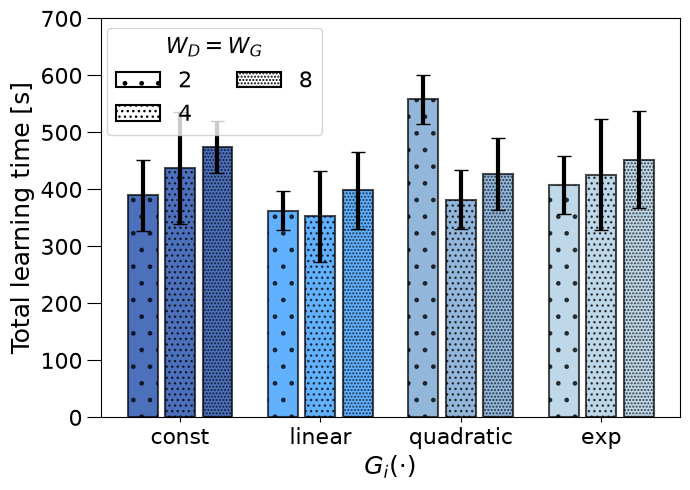

All x-axis labels found (ordered): ['const', 'linear', 'quadratic', 'exp']
saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/figA4/plot_c


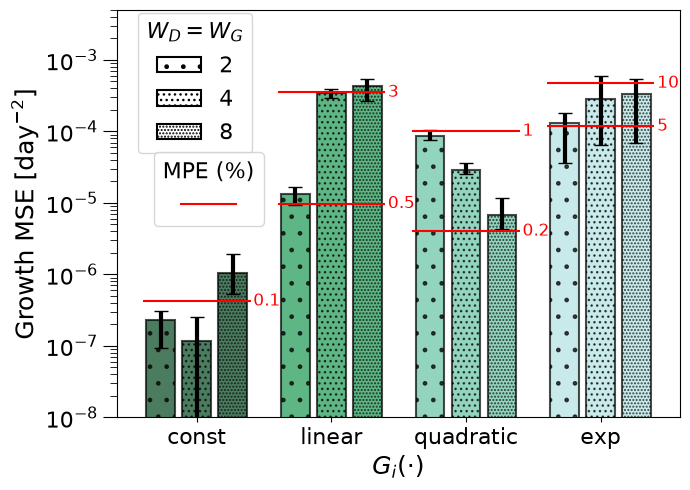

All x-axis labels found (ordered): ['const', 'linear', 'quadratic', 'exp']
saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case3/figA4/plot_d


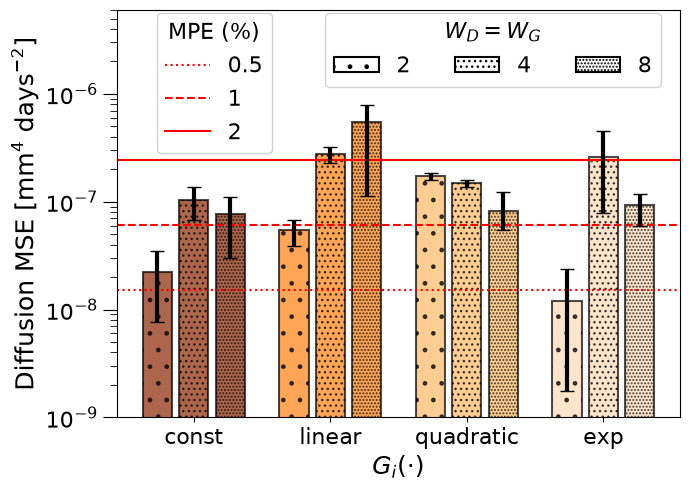

In [10]:
# Generate the width-sweep summary panels at fixed ES.
width_hatch_patterns = (".", "...", ".....")
width_growth_family_beta_list_nested = [[0.1], [0.5, 3], [0.2, 1], [5, 10]]
width_growth_family_mses_nested = []
for family_label, beta_values in zip(GROWTH_FAMILY_LABELS, width_growth_family_beta_list_nested):
    family_data_obj = load_case3_data_obj(grow_label=family_label)
    family_ground_truth_growth = make_ground_truth_growth(family_label, family_data_obj)
    width_growth_family_mses_nested.append(
        [compute_scaled_mse(family_ground_truth_growth, beta=beta) for beta in beta_values]
    )



# First plot of first row of figure A4
# ===================================
plot_final_loss_lst(
    width_family_models_list,
    plot_params=width_family_loss_plot_params,
    label_list=WIDTH_LABELS,
    name=str(FIGURE_A4_DIR / "plot_a"),
    bbox_to_anchor=(0.73, 1.0),
    y_label="Validation loss [a.u.]",
    legend_size=LEGEND_SIZE,
    x_label=r"$G_i(\cdot)$",
    figsize=(7, 5),
    axis_fontsizes=FONTSIZES,
    hatch_patterns=width_hatch_patterns,
    legend_title=r"$W_D=W_G$",
)


# Second plot of first row of figure A4
# ===================================
plot_total_run_times_lst(
    models_dics_list=width_family_models_list,
    plot_params=width_family_loss_plot_params,
    label_list=WIDTH_LABELS,
    legend_pos=(0.4, 0.68),
    legend_fontsize=LEGEND_SIZE,
    y_label="Total learning time [s]",
    x_label=r"$G_i(\cdot)$",
    name=str(FIGURE_A4_DIR / "plot_b"),
    figsize=(7, 5),
    legend_ncols=2,
    axis_fontsizes=FONTSIZES,
    hatch_patterns=width_hatch_patterns,
    y_scale="linear",
    y_lim=[0, 700],
    legend_title=r"$W_D=W_G$",
)

# First plot of second row of figure A4
# ===================================
plot_grow_mse_lst_extended(
    models_dics_list=width_family_models_list,
    plot_params=width_family_mse_plot_params,
    label_list=WIDTH_LABELS,
    name=str(FIGURE_A4_DIR / "plot_c"),
    figsize=(7, 5),
    colors=G_COLORS[: len(GROWTH_FAMILY_LABELS)],
    bbox_to_anchor=(0.26, 1.02),
    legend_size=LEGEND_SIZE,
    pe_bbox_to_anchor_offset=(0, -0.55),
    pe_label_list_nested=width_growth_family_beta_list_nested,
    pe_values_nested=width_growth_family_mses_nested,
    pe_linestyles_nested=growth_family_pe_linestyles_nested,
    pe_legend_ncols=4,
    y_label=r"Growth MSE [day$^{-2}$]",
    hatch_patterns=width_hatch_patterns,
    pe_legend_title="MPE (%)",
    x_label=r"$G_i(\cdot)$",
    y_lim=(1e-8, 5e-3),
    axis_fontsizes=FONTSIZES,
    legend_title=r"$W_D=W_G$",
)

# Second plot of second row of figure A4
# ===================================
plot_diff_mse_lst(
    models_dics_list=width_family_models_list,
    plot_params=width_diffusion_plot_params,
    label_list=WIDTH_LABELS,
    name=str(FIGURE_A4_DIR / "plot_d"),
    figsize=(7, 5),
    colors=D_COLORS[: len(GROWTH_FAMILY_LABELS)],
    bbox_to_anchor=(0.35, 1.02),
    legend_ncols=3,
    legend_size=16,
    pe_bbox_to_anchor_offset=(-0.3, 0),
    pe_label_list=[f"{mpe}" for mpe in RAW_MSES_DIFF],
    pe_values=MSES_DIFF,
    pe_linestyles=(":", "--", "-", "-."),
    pe_legend_ncols=1,
    hatch_patterns=width_hatch_patterns,
    pe_legend_title="MPE (%)",
    legend_title=r"$W_D=W_G$",
    x_label=r"$G_i(\cdot)$",
    axis_fontsizes=FONTSIZES,
    ylim=(1e-9, 6e-6),
)


## References

J. H. Lagergren et al. "Biologically-informed neural networks guide mechanistic modeling from sparse experimental data". In: *PLoS Comput Biol* 16.12 (2020), e1008462. DOI: [10.1371/journal.pcbi.1008462](https://doi.org/10.1371/journal.pcbi.1008462).
